# Neural Network Models for Object Recognition
## CIFAR-10 | Baseline CNN → Improved CNN → Transfer Learning (MobileNetV2)

**Optimised for:** Google Colab Free Tier (12GB RAM, T4 GPU)  
**Dataset:** CIFAR-10 — 60,000 images, 10 classes, 32×32 colour


```
Train Model 1 → save predictions + history → delete from RAM
Train Model 2 → save predictions + history → delete from RAM
Train Model 3 → save predictions + history → delete from RAM
Load all saved results → generate all charts and comparison
```

---
### Notebook Structure
- Section 1 — Setup
- Section 2 — Data Preparation & EDA
- Section 3 — Model 1: Baseline CNN
- Section 4 — Model 2: Improved CNN
- Section 5 — Model 3: Transfer Learning (MobileNetV2)
- Section 6 — Evaluation & All Charts
- Section 7 — Comparison
- Section 8 — Conclusions

---
## Section 1 — Setup

In [1]:
import os, gc, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU check ────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow : {tf.__version__}")
if gpus:
    print(f"GPU      : {gpus[0].name}")
else:
    print("No GPU")

# ── Global settings ──────────────────────────────────────────────────────────
CLASS_NAMES  = ['airplane','automobile','bird','cat','deer',
                'dog','frog','horse','ship','truck']
NUM_CLASSES  = 10
BATCH_SIZE   = 64
VAL_SPLIT    = 0.15
EPOCHS_BASE  = 50
EPOCHS_IMP   = 60
EPOCHS_TL    = 30
TL_IMG_SIZE  = 64     # 64×64 keeps GPU memory usage safe on free tier

# ── Results folder — everything saved here ───────────────────────────────────
os.makedirs('results', exist_ok=True)

print("\n Setup complete.")

TensorFlow : 2.19.0
GPU      : /physical_device:GPU:0

 Setup complete.


---
## Section 2 — Data Preparation & EDA

### Why three splits?
- **Training set** — the model learns from this directly
- **Validation set** — monitors progress during training, used by EarlyStopping and ReduceLROnPlateau. Never used for gradient updates.
- **Test set** — touched only once at the very end for final unbiased evaluation

Using the test set during training would cause **data leakage** — the model indirectly learns about test data and produces an overoptimistic accuracy score.

| Split | Samples | Purpose |
|---|---|---|
| Training | 42,500 | Model learns from this |
| Validation | 7,500 | Monitor training, tune hyperparameters |
| Test | 10,000 | Final unbiased evaluation only |

In [2]:
# ── Load CIFAR-10 ─────────────────────────────────────────────────────────────
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test       = y_test.flatten()

# ── Stratified split — preserves class balance in both sets ──────────────────
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=y_train_full
)

# Free raw full set — no longer needed
del x_train_full
gc.collect()

# ── Normalise to [0, 1] ───────────────────────────────────────────────────────
x_train_norm = x_train.astype('float32') / 255.0
x_val_norm   = x_val.astype('float32')   / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

print(f"Training   : {x_train_norm.shape[0]:,} images")
print(f"Validation : {x_val_norm.shape[0]:,} images")
print(f"Test       : {x_test_norm.shape[0]:,} images")
print("\n Data ready.")

Training   : 42,500 images
Validation : 7,500 images
Test       : 10,000 images

 Data ready.


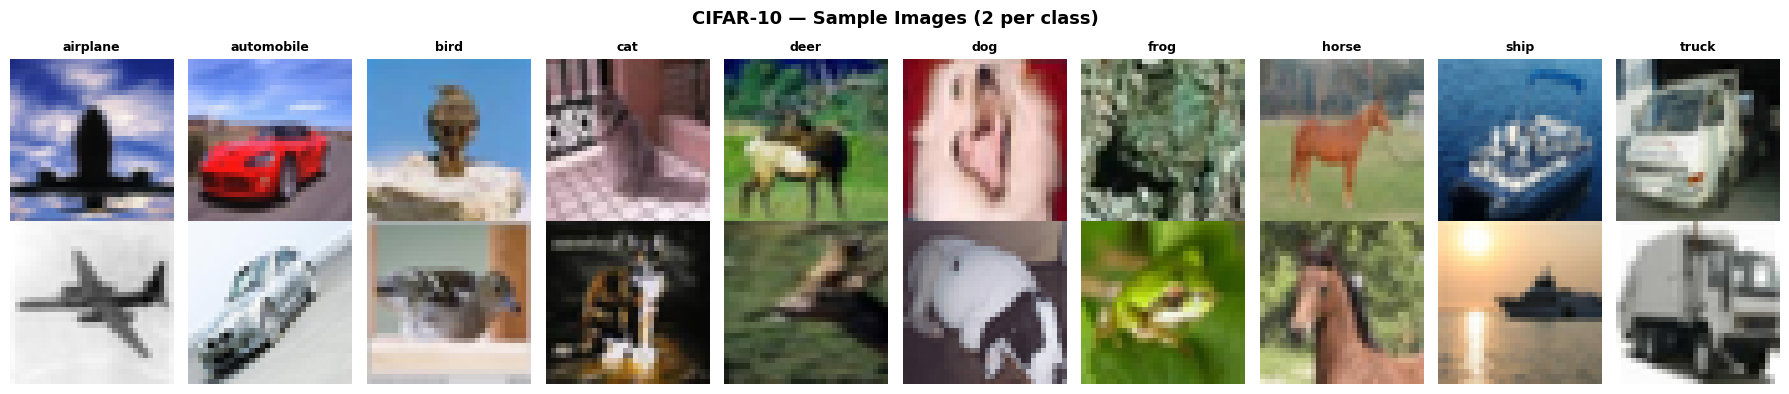

Saved: results/01_sample_images.png


In [3]:
# ── Sample images grid ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('CIFAR-10 — Sample Images (2 per class)', fontsize=13, fontweight='bold')
for col, cls in enumerate(range(NUM_CLASSES)):
    idxs = np.where(y_train == cls)[0][:2]
    for row, idx in enumerate(idxs):
        axes[row, col].imshow(x_train[idx])
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[cls], fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('results/01_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/01_sample_images.png")

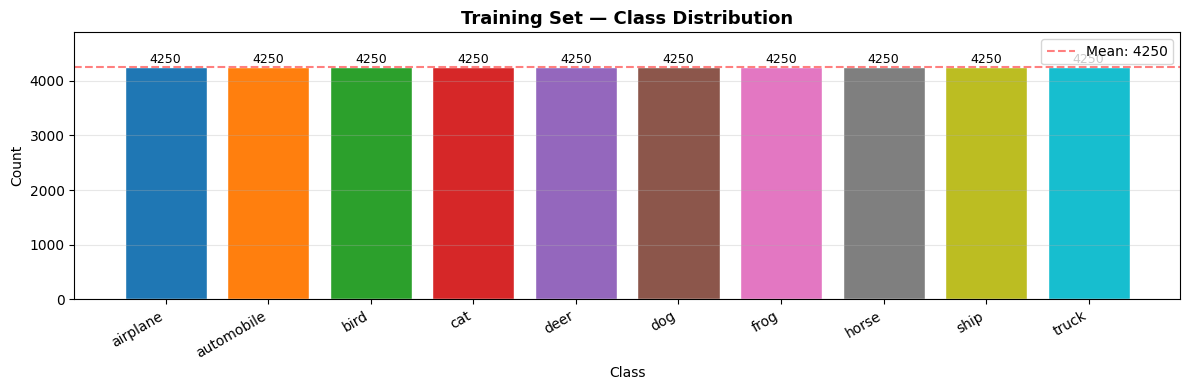

Saved: results/02_class_distribution.png
Note: Balanced dataset — accuracy is a reliable primary metric.


In [4]:
# ── Class distribution ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
counts  = [np.sum(y_train == i) for i in range(NUM_CLASSES)]
colors  = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
bars    = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='white')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontsize=9)
ax.axhline(y=np.mean(counts), color='red', linestyle='--', alpha=0.5,
           label=f'Mean: {np.mean(counts):.0f}')
ax.set_title('Training Set — Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylim(0, max(counts) * 1.15)
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('results/02_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/02_class_distribution.png")
print("Note: Balanced dataset — accuracy is a reliable primary metric.")

---
## Section 3 — Model 1: Baseline CNN

A simple CNN with no regularisation or augmentation. This is our **performance lower bound** — it shows what happens without any of the improvements we add in Model 2.

**Architecture:**
```
Input (32×32×3)
 → Conv2D(32 filters) + ReLU + MaxPool
 → Conv2D(64 filters) + ReLU + MaxPool
 → Conv2D(128 filters) + ReLU + MaxPool
 → Flatten → Dense(256) + ReLU
 → Dense(10) + Softmax
```

**Expected outcome:** High training accuracy, noticeably lower validation accuracy — a clear sign of overfitting. This motivates all the improvements in Model 2.

In [5]:
def build_baseline_cnn():
    model = keras.Sequential([
        keras.Input(shape=(32, 32, 3)),

        # Block 1 — detect basic features (edges, colours)
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),

        # Block 2 — detect more complex features
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),

        # Block 3 — detect high-level features
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')

    ], name='Baseline_CNN')
    return model


baseline_cnn = build_baseline_cnn()

baseline_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
baseline_cnn.summary()
print(f"\nTotal parameters: {baseline_cnn.count_params():,}")

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 620,362


In [6]:
print("Training Model 1 — Baseline CNN...")
print("-" * 50)

history_base = baseline_cnn.fit(
    x_train_norm, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_BASE,
    validation_data=(x_val_norm, y_val),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint('results/baseline_best.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=0)
    ],
    verbose=1
)

# ── Evaluate and save predictions ────────────────────────────────────────────
y_pred_base = np.argmax(baseline_cnn.predict(x_test_norm, verbose=0), axis=1)
np.save('results/y_pred_base.npy', y_pred_base)
np.save('results/history_base_acc',     np.array(history_base.history['accuracy']))
np.save('results/history_base_valacc',  np.array(history_base.history['val_accuracy']))
np.save('results/history_base_loss',    np.array(history_base.history['loss']))
np.save('results/history_base_valloss', np.array(history_base.history['val_loss']))

base_params = baseline_cnn.count_params()
np.save('results/base_params.npy', np.array([base_params]))

print(f"\n Baseline CNN done.")
print(f"   Best val accuracy : {max(history_base.history['val_accuracy'])*100:.2f}%")
print(f"   Epochs trained    : {len(history_base.history['accuracy'])}")

# ── Clear from memory ─────────────────────────────────────────────────────────
del baseline_cnn, history_base
gc.collect()
keras.backend.clear_session()
print("\n Memory cleared. Ready for Model 2.")

Training Model 1 — Baseline CNN...
--------------------------------------------------
Epoch 1/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4686 - loss: 1.4618 - val_accuracy: 0.5248 - val_loss: 1.3361
Epoch 2/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6356 - loss: 1.0392 - val_accuracy: 0.6164 - val_loss: 1.0722
Epoch 3/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6980 - loss: 0.8626 - val_accuracy: 0.6717 - val_loss: 0.9450
Epoch 4/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7396 - loss: 0.7457 - val_accuracy: 0.6980 - val_loss: 0.8698
Epoch 5/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7730 - loss: 0.6522 - val_accuracy: 0.7120 - val_loss: 0.8362
Epoch 6/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8043 - loss: 0.5695 - val_accuracy: 0.7068 - val_loss: 0.8814
Epoch 7/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8311 - loss: 0.4918 - val_accuracy: 0.7108 - val_loss: 0.9414
Epoch 8/50
665/6

---
## Section 4 — Model 2: Improved CNN

Same CNN idea as Model 1 but with targeted improvements to reduce overfitting and improve generalisation.

| Improvement | Why it helps |
|---|---|
| **Data Augmentation** | Model sees varied images → less memorisation |
| **Batch Normalisation** | Stabilises training, allows higher learning rates |
| **Dropout** | Randomly disables neurons → forces robust learning |
| **L2 Regularisation** | Penalises large weights → simpler, more general model |
| **More filters** | 64→128→256 → richer feature learning |
| **Global Avg Pooling** | Replaces Flatten → far fewer parameters |
| **ReduceLROnPlateau** | Halves learning rate when stuck → better convergence |

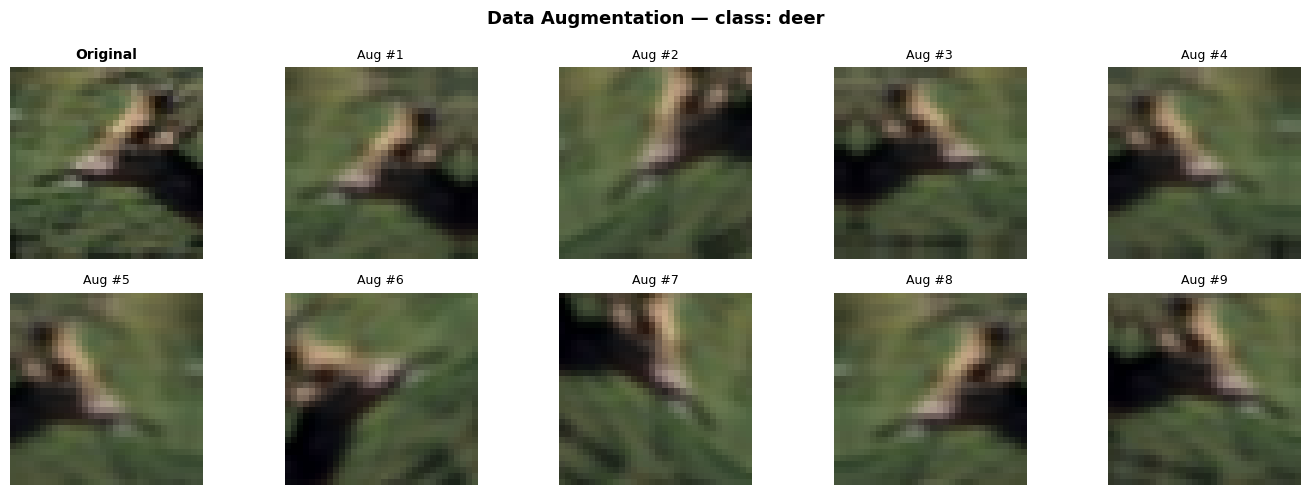

Saved: results/03_augmentation.png


In [7]:
# ── Augmentation layer ─────────────────────────
augmentation_layer = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

# ── Visualise augmentation ────────────────────────────────────────────────────
sample = x_train_norm[5:6]
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
fig.suptitle(f'Data Augmentation — class: {CLASS_NAMES[y_train[5]]}',
             fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i == 0:
        ax.imshow(sample[0])
        ax.set_title('Original', fontsize=10, fontweight='bold')
    else:
        aug = np.clip(augmentation_layer(sample, training=True)[0].numpy(), 0, 1)
        ax.imshow(aug)
        ax.set_title(f'Aug #{i}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('results/03_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/03_augmentation.png")

In [8]:
def build_improved_cnn():
    reg    = regularizers.l2(5e-4)
    inputs = keras.Input(shape=(32, 32, 3))

    # Augmentation — only runs when training=True
    x = augmentation_layer(inputs)

    # Block 1 — 64 filters
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2 — 128 filters
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.30)(x)

    # Block 3 — 256 filters
    x = layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, (3,3), padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.35)(x)

    # Global Average Pooling — fewer params than Flatten
    x = layers.GlobalAveragePooling2D()(x)

    # Dense head
    x = layers.Dense(512, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.45)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs, outputs, name='Improved_CNN')


improved_cnn = build_improved_cnn()
improved_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
improved_cnn.summary()
print(f"\nTotal parameters: {improved_cnn.count_params():,}")

Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,287,754 (4.91 MB)

 Trainable params: 1,284,938 (4.90 MB)

 Non-trainable params: 2,816 (11.00 KB)


Total parameters: 1,287,754


In [9]:
print("Training Model 2 — Improved CNN...")
print("-" * 50)

history_imp = improved_cnn.fit(
    x_train_norm, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_IMP,
    validation_data=(x_val_norm, y_val),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint('results/improved_best.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=0)
    ],
    verbose=1
)

# ── Evaluate and save predictions ────────────────────────────────────────────
y_pred_imp = np.argmax(improved_cnn.predict(x_test_norm, verbose=0), axis=1)
np.save('results/y_pred_imp.npy', y_pred_imp)
np.save('results/history_imp_acc',     np.array(history_imp.history['accuracy']))
np.save('results/history_imp_valacc',  np.array(history_imp.history['val_accuracy']))
np.save('results/history_imp_loss',    np.array(history_imp.history['loss']))
np.save('results/history_imp_valloss', np.array(history_imp.history['val_loss']))

imp_params = improved_cnn.count_params()
np.save('results/imp_params.npy', np.array([imp_params]))

print(f"\n Improved CNN done.")
print(f"   Best val accuracy : {max(history_imp.history['val_accuracy'])*100:.2f}%")
print(f"   Epochs trained    : {len(history_imp.history['accuracy'])}")

# ── Clear from memory ─────────────────────────────────────────────────────────
del improved_cnn, history_imp, augmentation_layer
gc.collect()
keras.backend.clear_session()
print("\n Memory cleared. Ready for Model 3.")

Training Model 2 — Improved CNN...
--------------------------------------------------
Epoch 1/60
665/665 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.3603 - loss: 2.2682 - val_accuracy: 0.3960 - val_loss: 2.0447 - learning_rate: 0.0010
Epoch 2/60
665/665 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.4931 - loss: 1.7484 - val_accuracy: 0.3896 - val_loss: 2.1049 - learning_rate: 0.0010
Epoch 3/60
665/665 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.5456 - loss: 1.5417 - val_accuracy: 0.2971 - val_loss: 3.1343 - learning_rate: 0.0010
Epoch 4/60
665/665 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.5811 - loss: 1.4447 - val_accuracy: 0.4648 - val_loss: 2.2656 - learning_rate: 0.0010
Epoch 5/60
665/665 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.6067 - loss: 1.3869 - val_accuracy: 0.4663 - val_loss: 2.1114 - learning_rate: 0.0010
Epoch 6/60
663/665 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6146 - loss: 1.3803
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00

---
## Section 5 — Model 3: Transfer Learning (MobileNetV2)

### What is Transfer Learning?
MobileNetV2 was pre-trained on **ImageNet** — 1.28 million images across 1000 classes. Its layers already know how to detect edges, textures, shapes, and objects. We reuse that knowledge instead of learning from scratch.

### Why MobileNetV2?
- Lightweight and fast — designed for efficiency
- Pre-trained on ImageNet — rich, general features
- One of the two options specified in the assignment brief

### Two-phase training
- **Phase 1** — freeze the entire MobileNetV2 base, train only the new classification head. Fast, safe, establishes a good starting point.
- **Phase 2** — unfreeze the top 30 layers and fine-tune with a very small learning rate (0.00001). Slightly adjusts pre-trained features to better suit CIFAR-10.

### Memory strategy
Images are resized on the fly using `tf.data` — they are **never all stored in RAM at once**. This is what prevents the memory crash.


In [10]:
# ── tf.data pipeline — resizes images on the fly, no RAM overhead ────────────
# Instead of resizing all 42,500 images and storing them,
# we create a pipeline that resizes each batch just before it's needed.

def make_tl_dataset(x_imgs, y_labels, training=False):
    """
    Creates a tf.data pipeline that:
    1. Takes normalised [0,1] images
    2. Resizes to TL_IMG_SIZE×TL_IMG_SIZE on the fly
    3. Applies MobileNetV2 preprocessing (scales to [-1, 1])
    4. Optionally shuffles (training only)
    """
    def preprocess(image, label):
        image = tf.image.resize(image, [TL_IMG_SIZE, TL_IMG_SIZE])
        image = tf.keras.applications.mobilenet_v2.preprocess_input(image * 255.0)
        return image, label

    ds = tf.data.Dataset.from_tensor_slices((x_imgs, y_labels))
    if training:
        ds = ds.shuffle(buffer_size=4000, seed=SEED)
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_tl_ds = make_tl_dataset(x_train_norm, y_train, training=True)
val_tl_ds   = make_tl_dataset(x_val_norm,   y_val,   training=False)
test_tl_ds  = make_tl_dataset(x_test_norm,  y_test,  training=False)

print(f" tf.data pipelines ready.")
print(f"   Images resized to {TL_IMG_SIZE}×{TL_IMG_SIZE} on the fly — no RAM overhead.")

 tf.data pipelines ready.
   Images resized to 64×64 on the fly — no RAM overhead.


In [11]:
# ── Build MobileNetV2 model ───────────────────────────────────────────────────
def build_mobilenet_model():
    inputs = keras.Input(shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3))

    # Augmentation inside the model
    x = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ], name='aug_tl')(inputs)

    # Pre-trained MobileNetV2 base — frozen for Phase 1
    base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        alpha=1.0
    )
    base.trainable = False  # Phase 1: freeze

    # New classification head
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=outputs, name='MobileNetV2_TL')
    return model, base


tl_model, mobilenet_base = build_mobilenet_model()

total     = tl_model.count_params()
trainable = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
print(f"Total parameters      : {total:,}")
print(f"Trainable (head only) : {trainable:,}")
print(f"Frozen (base)         : {total - trainable:,}")

Total parameters      : 2,589,514
Trainable (head only) : 331,018
Frozen (base)         : 2,258,496


In [12]:
# ── Phase 1: Feature Extraction ───────────────────────────────────────────────
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer Learning — Phase 1: Feature Extraction")
print("MobileNetV2 base is frozen — training new head only")
print("-" * 50)

history_tl1 = tl_model.fit(
    train_tl_ds,
    epochs=15,
    validation_data=val_tl_ds,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint('results/tl_phase1_best.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=0)
    ],
    verbose=1
)

print(f"\n Phase 1 done. Best val accuracy: {max(history_tl1.history['val_accuracy'])*100:.2f}%")

Transfer Learning — Phase 1: Feature Extraction
MobileNetV2 base is frozen — training new head only
--------------------------------------------------
Epoch 1/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.5409 - loss: 1.3584 - val_accuracy: 0.6869 - val_loss: 0.9586
Epoch 2/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.5958 - loss: 1.1994 - val_accuracy: 0.6923 - val_loss: 0.9338
Epoch 3/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.6080 - loss: 1.1625 - val_accuracy: 0.7037 - val_loss: 0.9142
Epoch 4/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.6162 - loss: 1.1524 - val_accuracy: 0.7077 - val_loss: 0.9100
Epoch 5/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6185 - loss: 1.1487 - val_accuracy: 0.7037 - val_loss: 0.9293
Epoch 6/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.6244 - loss: 1.1348 - val_accuracy: 0.7071 - val_loss: 0.9139
Epoch 7/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6

In [13]:
# ── Phase 2: Fine-tuning ──────────────────────────────────────────────────────
# Unfreeze only the last 30 layers of MobileNetV2
# Earlier layers detect simple universal features
# Later layers are more task-specific — fine-tuning helps here

mobilenet_base.trainable = True
FINE_TUNE_FROM = len(mobilenet_base.layers) - 30
for layer in mobilenet_base.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

trainable_now = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
print(f"Trainable params after unfreeze: {trainable_now:,}")

# Very small LR — avoids overwriting pre-trained knowledge
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTransfer Learning — Phase 2: Fine-tuning")
print("Top 30 layers unfrozen — learning rate = 0.00001")
print("-" * 50)

history_tl2 = tl_model.fit(
    train_tl_ds,
    epochs=EPOCHS_TL,
    validation_data=val_tl_ds,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint('results/tl_phase2_best.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=0)
    ],
    verbose=1
)

print(f"\n Phase 2 done. Best val accuracy: {max(history_tl2.history['val_accuracy'])*100:.2f}%")

Trainable params after unfreeze: 1,857,418

Transfer Learning — Phase 2: Fine-tuning
Top 30 layers unfrozen — learning rate = 0.00001
--------------------------------------------------
Epoch 1/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.5411 - loss: 1.3968 - val_accuracy: 0.7055 - val_loss: 0.9366 - learning_rate: 1.0000e-05
Epoch 2/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.5992 - loss: 1.2152 - val_accuracy: 0.7157 - val_loss: 0.9337 - learning_rate: 1.0000e-05
Epoch 3/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.6293 - loss: 1.1344 - val_accuracy: 0.7284 - val_loss: 0.8889 - learning_rate: 1.0000e-05
Epoch 4/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.6429 - loss: 1.0822 - val_accuracy: 0.7384 - val_loss: 0.8446 - learning_rate: 1.0000e-05
Epoch 5/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 25s 38ms/step - accuracy: 0.6616 - loss: 1.0480 - val_accuracy: 0.7465 - val_loss: 0.8132 - learning_rate: 1.0000e-05
Epoch 6/30
665/665 ━━━━━━

In [14]:
# ── Evaluate and save TL results ─────────────────────────────────────────────
y_pred_tl = np.argmax(tl_model.predict(test_tl_ds, verbose=0), axis=1)
np.save('results/y_pred_tl.npy', y_pred_tl)

# Merge phase 1 + phase 2 histories
tl_acc     = history_tl1.history['accuracy']     + history_tl2.history['accuracy']
tl_valacc  = history_tl1.history['val_accuracy'] + history_tl2.history['val_accuracy']
tl_loss    = history_tl1.history['loss']         + history_tl2.history['loss']
tl_valloss = history_tl1.history['val_loss']     + history_tl2.history['val_loss']
tl_phase2_start = len(history_tl1.history['accuracy'])

np.save('results/history_tl_acc',       np.array(tl_acc))
np.save('results/history_tl_valacc',    np.array(tl_valacc))
np.save('results/history_tl_loss',      np.array(tl_loss))
np.save('results/history_tl_valloss',   np.array(tl_valloss))
np.save('results/tl_phase2_start.npy',  np.array([tl_phase2_start]))

tl_params = tl_model.count_params()
np.save('results/tl_params.npy', np.array([tl_params]))

print(f" Transfer Learning results saved.")
print(f"   Epochs Phase 1 : {len(history_tl1.history['accuracy'])}")
print(f"   Epochs Phase 2 : {len(history_tl2.history['accuracy'])}")

# ── Clear from memory ─────────────────────────────────────────────────────────
del tl_model, mobilenet_base, history_tl1, history_tl2
del train_tl_ds, val_tl_ds, test_tl_ds
gc.collect()
keras.backend.clear_session()
print("\n Memory cleared. Ready for evaluation.")

 Transfer Learning results saved.
   Epochs Phase 1 : 12
   Epochs Phase 2 : 30

 Memory cleared. Ready for evaluation.


---
## Section 6 — Evaluation & Charts

All three models have been trained and their predictions saved to disk.

### Metrics explained
- **Accuracy** — what % of all test images were correctly classified
- **Precision** — of all times we predicted class X, how often it was right.
- **Recall** — of all real class X images, how many were correctly found.
- **F1-Score** — harmonic mean of precision and recall — best single metric when both matter
- **Confusion Matrix** — grid showing exactly which classes get confused with which

In [15]:
# ── Load all saved predictions ────────────────────────────────────────────────
y_pred_base = np.load('results/y_pred_base.npy')
y_pred_imp  = np.load('results/y_pred_imp.npy')
y_pred_tl   = np.load('results/y_pred_tl.npy')

# Load histories
hist_base = {
    'accuracy':     np.load('results/history_base_acc.npy'),
    'val_accuracy': np.load('results/history_base_valacc.npy'),
    'loss':         np.load('results/history_base_loss.npy'),
    'val_loss':     np.load('results/history_base_valloss.npy'),
}
hist_imp = {
    'accuracy':     np.load('results/history_imp_acc.npy'),
    'val_accuracy': np.load('results/history_imp_valacc.npy'),
    'loss':         np.load('results/history_imp_loss.npy'),
    'val_loss':     np.load('results/history_imp_valloss.npy'),
}
hist_tl = {
    'accuracy':     np.load('results/history_tl_acc.npy'),
    'val_accuracy': np.load('results/history_tl_valacc.npy'),
    'loss':         np.load('results/history_tl_loss.npy'),
    'val_loss':     np.load('results/history_tl_valloss.npy'),
}
tl_phase2_start = int(np.load('results/tl_phase2_start.npy')[0])
base_params     = int(np.load('results/base_params.npy')[0])
imp_params      = int(np.load('results/imp_params.npy')[0])
tl_params       = int(np.load('results/tl_params.npy')[0])

print("All results loaded.")

# ── Compute metrics ───────────────────────────────────────────────────────────
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    return acc, p, r, f1

base_m = get_metrics(y_test, y_pred_base)
imp_m  = get_metrics(y_test, y_pred_imp)
tl_m   = get_metrics(y_test, y_pred_tl)

print("\n" + "="*55)
print("  FINAL TEST SET RESULTS")
print("="*55)
for name, m in [('Baseline CNN', base_m),
                ('Improved CNN', imp_m),
                ('MobileNetV2 TL', tl_m)]:
    print(f"\n  {name}")
    print(f"    Accuracy  : {m[0]*100:.2f}%")
    print(f"    Precision : {m[1]*100:.2f}%")
    print(f"    Recall    : {m[2]*100:.2f}%")
    print(f"    F1-Score  : {m[3]*100:.2f}%")
print("="*55)

All results loaded.

  FINAL TEST SET RESULTS

  Baseline CNN
    Accuracy  : 71.26%
    Precision : 72.05%
    Recall    : 71.26%
    F1-Score  : 71.23%

  Improved CNN
    Accuracy  : 85.88%
    Precision : 86.49%
    Recall    : 85.88%
    F1-Score  : 85.78%

  MobileNetV2 TL
    Accuracy  : 82.25%
    Precision : 82.19%
    Recall    : 82.25%
    F1-Score  : 82.12%


In [16]:
# ── Per-class classification reports ─────────────────────────────────────────
for name, preds in [('Baseline CNN',   y_pred_base),
                    ('Improved CNN',   y_pred_imp),
                    ('MobileNetV2 TL', y_pred_tl)]:
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(classification_report(y_test, preds, target_names=CLASS_NAMES))


──────────────────────────────────────────────────
  Baseline CNN
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    airplane       0.75      0.77      0.76      1000
  automobile       0.83      0.86      0.84      1000
        bird       0.56      0.69      0.62      1000
         cat       0.52      0.55      0.53      1000
        deer       0.77      0.52      0.62      1000
         dog       0.62      0.60      0.61      1000
        frog       0.85      0.71      0.78      1000
       horse       0.70      0.80      0.74      1000
        ship       0.81      0.84      0.83      1000
       truck       0.79      0.79      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000


──────────────────────────────────────────────────
  Improved CNN
──────────────────────────────────────────────────
     

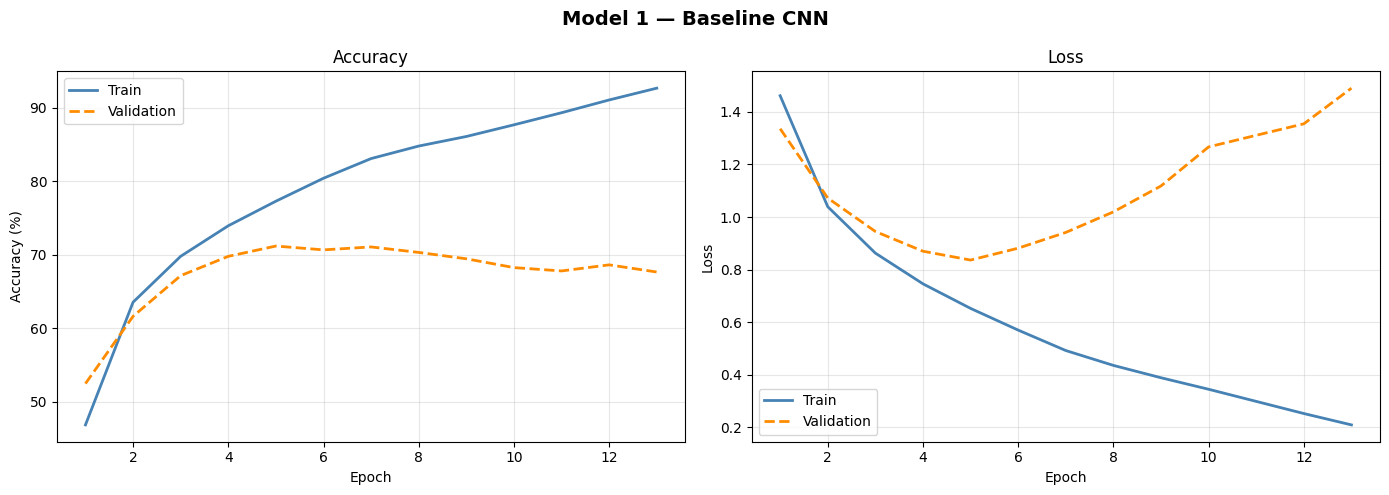

Saved: results/04_curves_baseline.png


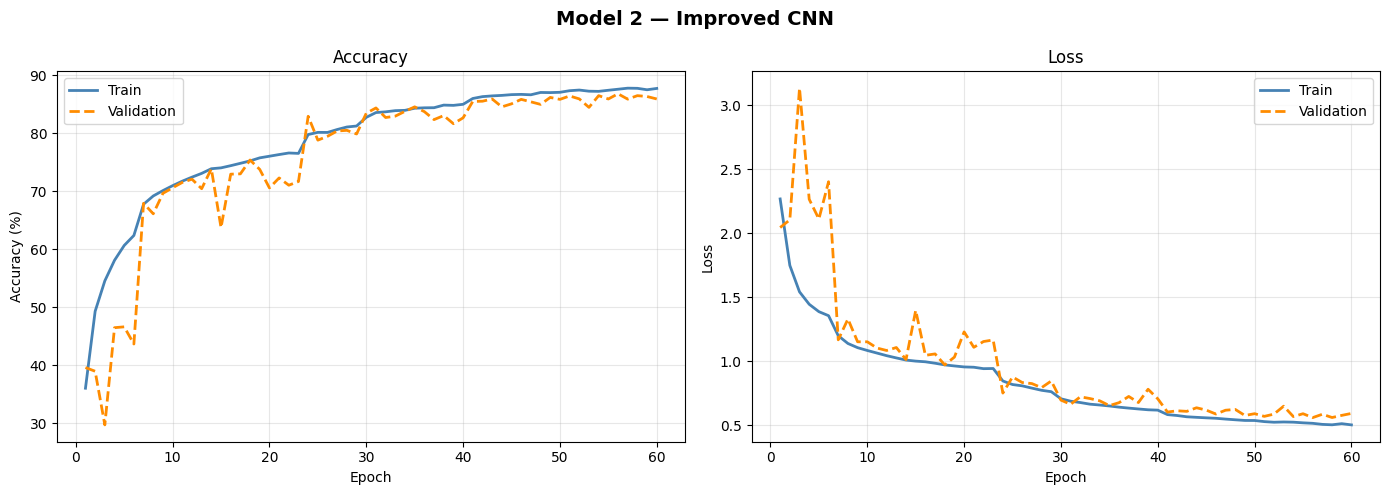

Saved: results/05_curves_improved.png


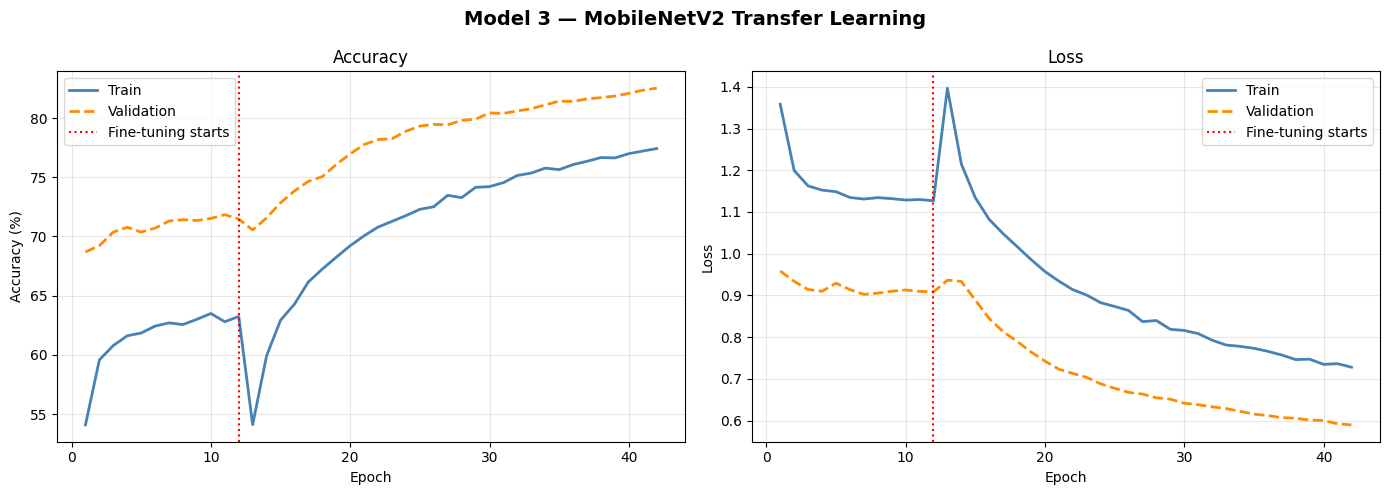

Saved: results/06_curves_tl.png


In [17]:
# ── Learning curves ───────────────────────────────────────────────────────────
def plot_learning_curves(hist, title, save_path, phase2_start=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    epochs = range(1, len(hist['accuracy']) + 1)

    for ax, train_key, val_key, ylabel in [
        (ax1, 'accuracy',     'val_accuracy', 'Accuracy (%)'),
        (ax2, 'loss',         'val_loss',     'Loss')
    ]:
        vals = hist[train_key]
        if ylabel.startswith('Acc'):
            vals = [v*100 for v in vals]
            vvals = [v*100 for v in hist[val_key]]
        else:
            vvals = hist[val_key]

        ax.plot(epochs, vals,  label='Train',      color='steelblue',  lw=2)
        ax.plot(epochs, vvals, label='Validation', color='darkorange', lw=2, linestyle='--')
        if phase2_start:
            ax.axvline(x=phase2_start, color='red', linestyle=':',
                       lw=1.5, label='Fine-tuning starts')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel.split(' ')[0])
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


plot_learning_curves(hist_base, 'Model 1 — Baseline CNN',
                     'results/04_curves_baseline.png')
plot_learning_curves(hist_imp,  'Model 2 — Improved CNN',
                     'results/05_curves_improved.png')
plot_learning_curves(hist_tl,   'Model 3 — MobileNetV2 Transfer Learning',
                     'results/06_curves_tl.png',
                     phase2_start=tl_phase2_start)

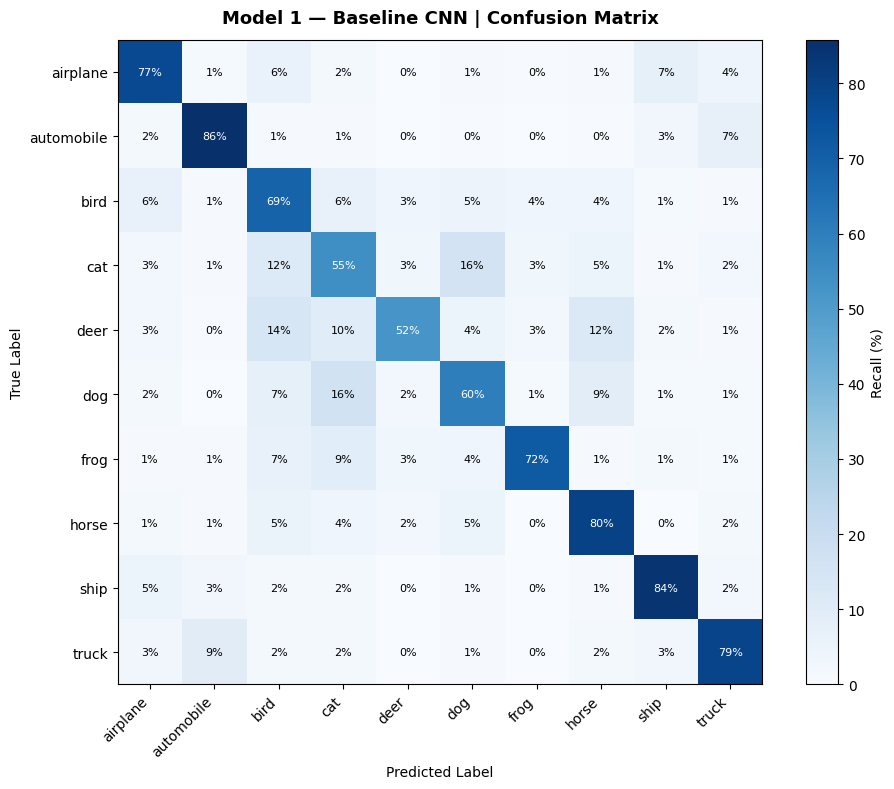

Saved: results/07_cm_baseline.png


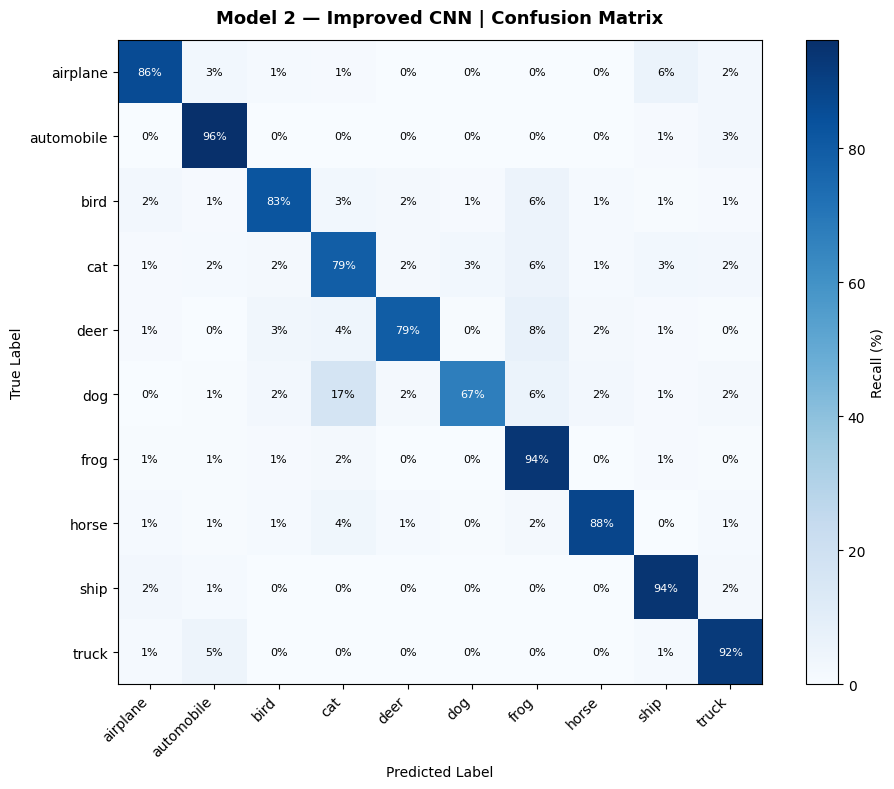

Saved: results/08_cm_improved.png


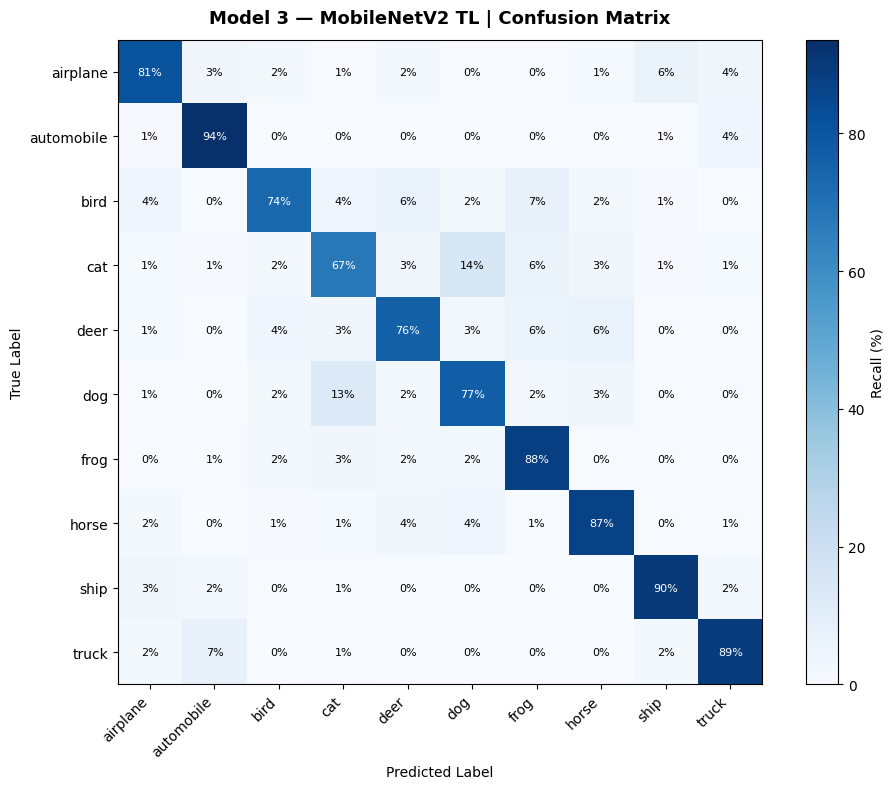

Saved: results/09_cm_tl.png


In [18]:
# ── Confusion matrices ────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_pct, cmap='Blues')
    plt.colorbar(im, ax=ax, label='Recall (%)')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(CLASS_NAMES, fontsize=10)
    thresh = cm_pct.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_pct[i,j]:.0f}%", ha='center', va='center',
                    fontsize=8,
                    color='white' if cm_pct[i, j] > thresh else 'black')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


plot_confusion_matrix(y_test, y_pred_base,
                      'Model 1 — Baseline CNN | Confusion Matrix',
                      'results/07_cm_baseline.png')
plot_confusion_matrix(y_test, y_pred_imp,
                      'Model 2 — Improved CNN | Confusion Matrix',
                      'results/08_cm_improved.png')
plot_confusion_matrix(y_test, y_pred_tl,
                      'Model 3 — MobileNetV2 TL | Confusion Matrix',
                      'results/09_cm_tl.png')

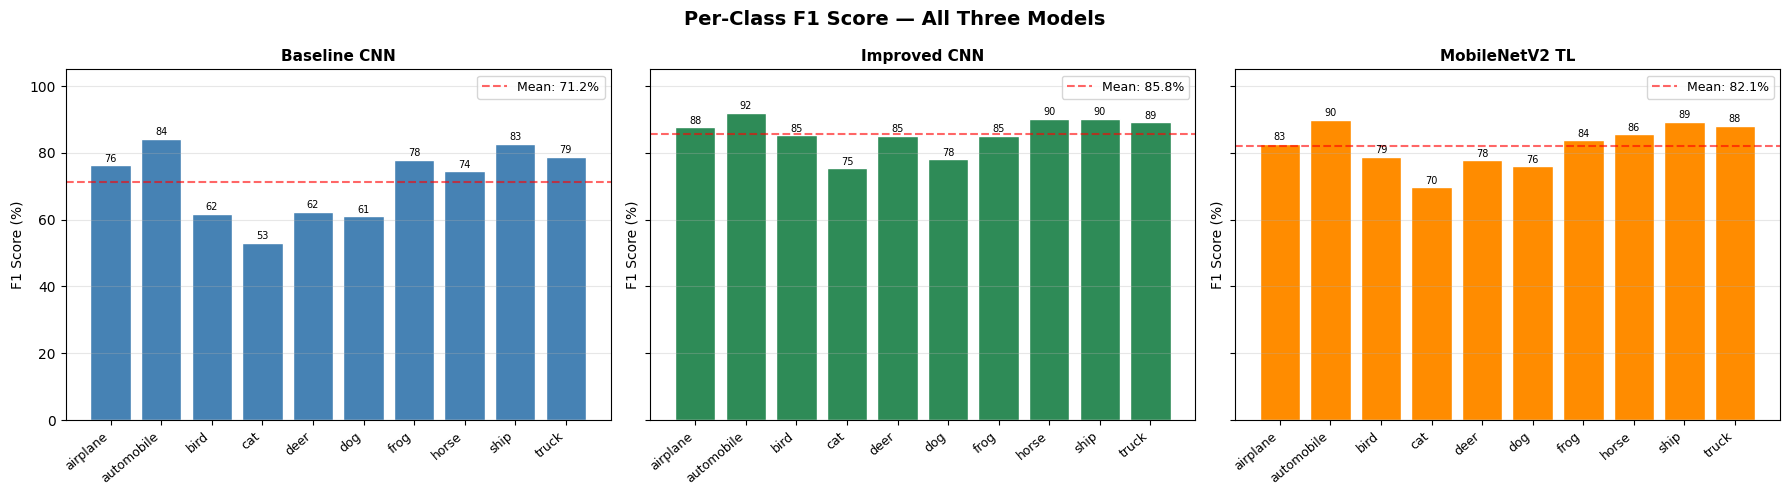

Saved: results/10_per_class_f1.png


In [19]:
# ── Per-class F1 scores — all 3 models side by side ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Per-Class F1 Score — All Three Models', fontsize=14, fontweight='bold')

for ax, (name, preds, color) in zip(axes, [
    ('Baseline CNN',   y_pred_base, 'steelblue'),
    ('Improved CNN',   y_pred_imp,  'seagreen'),
    ('MobileNetV2 TL', y_pred_tl,   'darkorange')
]):
    _, _, f1, _ = precision_recall_fscore_support(y_test, preds, average=None)
    bars = ax.bar(CLASS_NAMES, f1*100, color=color, edgecolor='white')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=9)
    ax.set_ylim(0, 105)
    ax.set_ylabel('F1 Score (%)')
    ax.axhline(y=np.mean(f1)*100, color='red', linestyle='--', alpha=0.6,
               label=f'Mean: {np.mean(f1)*100:.1f}%')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for bar, score in zip(bars, f1):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{score*100:.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('results/10_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/10_per_class_f1.png")

---
## Section 7 — Comparison


In [20]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model': ['Baseline CNN', 'Improved CNN', 'MobileNetV2 TL'],
    'Train Acc':  [f"{max(hist_base['accuracy'])*100:.1f}%",
                   f"{max(hist_imp['accuracy'])*100:.1f}%",
                   f"{max(hist_tl['accuracy'])*100:.1f}%"],
    'Val Acc':    [f"{max(hist_base['val_accuracy'])*100:.1f}%",
                   f"{max(hist_imp['val_accuracy'])*100:.1f}%",
                   f"{max(hist_tl['val_accuracy'])*100:.1f}%"],
    'Test Acc':   [f"{base_m[0]*100:.1f}%", f"{imp_m[0]*100:.1f}%", f"{tl_m[0]*100:.1f}%"],
    'Macro F1':   [f"{base_m[3]*100:.1f}%", f"{imp_m[3]*100:.1f}%", f"{tl_m[3]*100:.1f}%"],
    'Epochs':     [str(len(hist_base['accuracy'])),
                   str(len(hist_imp['accuracy'])),
                   str(len(hist_tl['accuracy']))],
    'Parameters': [f"{base_params:,}", f"{imp_params:,}", f"{tl_params:,}"],
    'Pre-trained':['No', 'No', 'Yes (ImageNet)']
})

print(summary.to_string(index=False))
summary.to_csv('results/11_model_summary.csv', index=False)
print("\nSaved: results/11_model_summary.csv")

         Model Train Acc Val Acc Test Acc Macro F1 Epochs Parameters    Pre-trained
  Baseline CNN     92.7%   71.2%    71.3%    71.2%     13    620,362             No
  Improved CNN     87.8%   86.8%    85.9%    85.8%     60  1,287,754             No
MobileNetV2 TL     77.4%   82.5%    82.2%    82.1%     42  2,589,514 Yes (ImageNet)

Saved: results/11_model_summary.csv


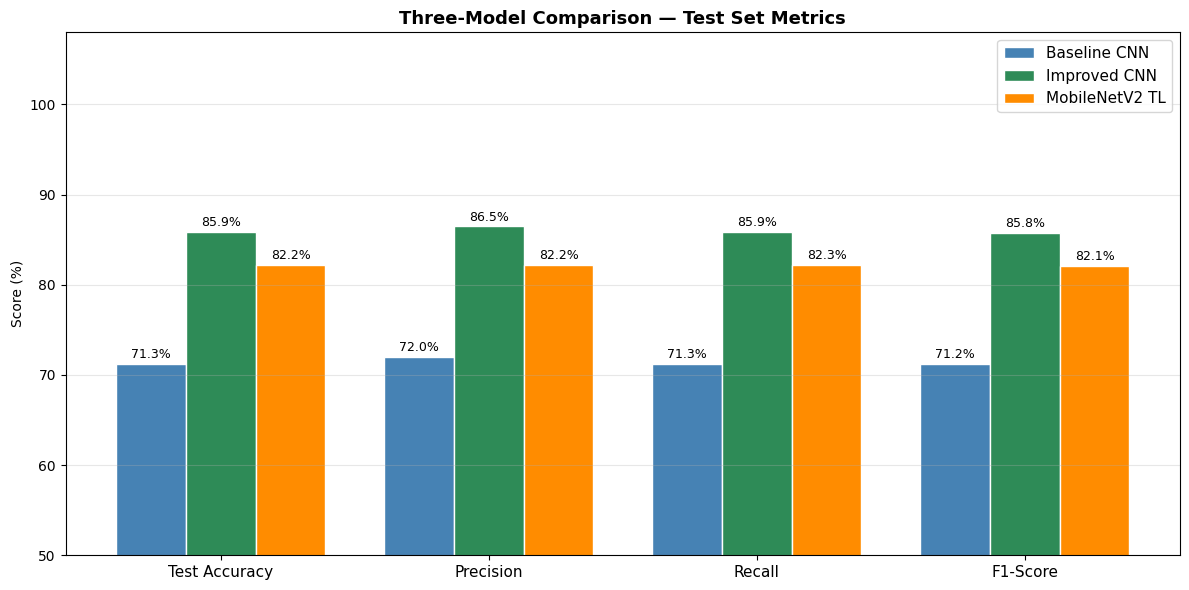

Saved: results/12_model_comparison.png


In [21]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
metrics_labels = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
x     = np.arange(len(metrics_labels))
width = 0.26

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width,   [v*100 for v in base_m], width,
            label='Baseline CNN',   color='steelblue',  edgecolor='white')
b2 = ax.bar(x,           [v*100 for v in imp_m],  width,
            label='Improved CNN',   color='seagreen',   edgecolor='white')
b3 = ax.bar(x + width,   [v*100 for v in tl_m],   width,
            label='MobileNetV2 TL', color='darkorange', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_ylim(50, 108)
ax.set_title('Three-Model Comparison — Test Set Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/12_model_comparison.png")